In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

In [ ]:
# GRIDWORLD

class GridWorld:
    def __init__(self, nrows=4, ncols=4, terminals=None,
                 default_reward=-1.0, slip_prob=0.0):
        self.nrows      = nrows
        self.ncols      = ncols
        self.nS         = nrows * ncols
        self.nA         = 4
        self.terminal_states = set(terminals or [])
        self.randomness = slip_prob          
        self.P          = self._build_model()

    
    def to_pos(self, s):   return divmod(s, self.ncols)
    def to_state(self, r, c): return r * self.ncols + c

    def render_ascii(self):
        symbols = {s: 'T' if s in self.terminal_states else '.' for s in range(self.nS)}
        for r in range(self.nrows):
            print(' '.join(symbols[self.to_state(r, c)] for c in range(self.ncols)))
        print()

    def _build_model(self):
        T     = {s: {a: [] for a in range(self.nA)} for s in range(self.nS)}
        moves = [(-1,0),(0,1),(1,0),(0,-1)]

        for s in range(self.nS):
            if s in self.terminal_states:
                for a in range(self.nA):
                    T[s][a] = [(1.0, s, 0, True)]
                continue

            r, c = self.to_pos(s)
            for a in range(self.nA):
                if self.randomness == 0:
                    choices = [(a, 1.0)]
                else:
                    left  = (a - 1) % 4
                    right = (a + 1) % 4
                    choices = [
                        (a,     1 - self.randomness),
                        (left,  self.randomness / 2),
                        (right, self.randomness / 2),
                    ]

                outcomes = {}
                for act, prob in choices:
                    dr, dc = moves[act]
                    nr = min(max(r + dr, 0), self.nrows - 1)
                    nc = min(max(c + dc, 0), self.ncols - 1)
                    ns   = self.to_state(nr, nc)
                    done = ns in self.terminal_states
                    key  = (ns, self.default_reward if hasattr(self,'default_reward') else -1, done)
                    outcomes[key] = outcomes.get(key, 0) + prob

                T[s][a] = [(p, ns, rew, d) for (ns, rew, d), p in outcomes.items()]

        return T

GridEnv = GridWorld

In [ ]:
# POLICY EVALUATION  

def evaluate_policy_limited(P, policy, nS, gamma=0.9, sweeps=5):
    V = np.zeros(nS)
    for _ in range(sweeps):
        new_V = np.copy(V)
        for s in range(nS):
            val = 0
            for a, prob_a in enumerate(policy[s]):
                for prob, ns, reward, done in P[s][a]:
                    val += prob_a * prob * (reward + gamma * (0 if done else V[ns]))
            new_V[s] = val
        V = new_V
    return V

In [ ]:
# POLICY IMPROVEMENT

def improve_policy(P, V, nS, nA, gamma=0.9):
    policy = np.zeros((nS, nA))
    for s in range(nS):
        q_vals = []
        for a in range(nA):
            q = sum(prob * (reward + gamma * (0 if done else V[ns]))
                    for prob, ns, reward, done in P[s][a])
            q_vals.append(q)
        policy[s, np.argmax(q_vals)] = 1
    return policy

In [ ]:
# POLICY ITERATION

def policy_iteration(P, nS, nA, gamma=0.9, theta=1e-6,
                     eval_synchronous=True, sweeps=5):
    policy = np.ones((nS, nA)) / nA
    value_hist, policy_hist, deltas, times = [], [], [], []
    start_total = time.perf_counter()

    while True:
        start = time.perf_counter()
        V         = evaluate_policy_limited(P, policy, nS, gamma, sweeps)
        new_policy = improve_policy(P, V, nS, nA, gamma)

        value_hist.append(V.copy())
        policy_hist.append(new_policy.copy())

        delta = np.max(np.abs(new_policy - policy))
        deltas.append(delta)
        times.append(time.perf_counter() - start)

        if np.array_equal(policy, new_policy):
            break
        policy = new_policy

    total_time = time.perf_counter() - start_total
    iters      = len(deltas)
    return policy, V, policy_hist, value_hist, deltas, times, iters, total_time

In [ ]:
# VALUE ITERATION

def value_iteration(P, nS, nA, gamma=0.9, theta=5e-2, synchronous=True):
    V = np.zeros(nS)
    value_hist, deltas, times = [], [], []
    start_total = time.perf_counter()

    while True:
        start = time.perf_counter()
        delta = 0
        new_V = np.copy(V)

        for s in range(nS):
            q_vals = [
                sum(prob * (reward + gamma * (0 if done else V[ns]))
                    for prob, ns, reward, done in P[s][a])
                for a in range(nA)
            ]
            best   = max(q_vals)
            delta  = max(delta, abs(V[s] - best))
            new_V[s] = best

        V = new_V
        value_hist.append(V.copy())
        deltas.append(delta)
        times.append(time.perf_counter() - start)

        if delta < theta:
            break

    policy     = improve_policy(P, V, nS, nA, gamma)
    total_time = time.perf_counter() - start_total
    iters      = len(deltas)
    return policy, V, value_hist, deltas, times, iters, total_time


In [ ]:
# VISUALIZATION  

def plot_value_sequence(V_history, nrows, ncols, title_prefix='V iter'):
    n    = len(V_history)
    cols = min(6, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = axes.flatten()
    for i, V in enumerate(V_history):
        grid = np.array(V).reshape((nrows, ncols))
        axes[i].imshow(grid, origin='upper', cmap='coolwarm')
        axes[i].set_title(f'{title_prefix} {i}')
        for (x, y), val in np.ndenumerate(grid):
            axes[i].text(y, x, f'{val:.2f}', ha='center', va='center', fontsize=8)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()


def plot_policy_sequence(policy_history, nrows, ncols, title_prefix='policy'):
    n    = len(policy_history)
    cols = min(6, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = axes.flatten()
    action_vec = {0:(0,-1), 1:(1,0), 2:(0,1), 3:(-1,0)}
    for i, pol in enumerate(policy_history):
        mat = np.zeros((nrows, ncols, 2))
        for s in range(nrows*ncols):
            r, c    = divmod(s, ncols)
            a       = np.argmax(pol[s])
            dx, dy  = action_vec[a]
            mat[r,c,0] = dx
            mat[r,c,1] = dy
        X, Y = np.meshgrid(np.arange(ncols), np.arange(nrows))
        axes[i].quiver(X, Y, mat[:,:,0], -mat[:,:,1])
        axes[i].invert_yaxis()
        axes[i].set_title(f'{title_prefix} {i}')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()


def plot_convergence(deltas_list, labels,
                     title='Convergence (delta per iteration)'):
    plt.figure(figsize=(6, 4))
    for deltas, lab in zip(deltas_list, labels):
        plt.plot(deltas, label=lab)
    plt.yscale('log')
    plt.legend()
    plt.xlabel('Iteration')
    plt.ylabel('Max |delta|')
    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_times(times_list, labels,
               title='Wall-clock times per outer-iteration'):
    plt.figure(figsize=(6, 4))
    for times, lab in zip(times_list, labels):
        plt.plot(times, label=lab)
    plt.legend()
    plt.xlabel('Outer Iteration')
    plt.ylabel('Seconds')
    plt.title(title)
    plt.grid(True)
    plt.show()

In [8]:
def _plot_env(name, pi_result, vi_result):
    _, _, _, _, deltas_pi, times_pi, _, _ = pi_result
    _, _, _,    deltas_vi, times_vi, _, _ = vi_result

    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    fig.suptitle(name, fontsize=13)

    axes[0,0].semilogy(deltas_pi, marker='o', markersize=4, color='#378ADD')
    axes[0,0].set_title('PI — delta per iteration')
    axes[0,0].set_xlabel('outer iteration'); axes[0,0].set_ylabel('max |Δpolicy|')

    axes[0,1].semilogy(deltas_vi, marker='o', markersize=4, color='#1D9E75')
    axes[0,1].set_title('VI — delta per iteration')
    axes[0,1].set_xlabel('sweep'); axes[0,1].set_ylabel('max |ΔV|')

    axes[1,0].bar(range(len(times_pi)), times_pi, color='#378ADD', alpha=0.8)
    axes[1,0].set_title('PI — wall-clock time per iteration')
    axes[1,0].set_xlabel('outer iteration'); axes[1,0].set_ylabel('seconds')

    axes[1,1].bar(range(len(times_vi)), times_vi, color='#1D9E75', alpha=0.8)
    axes[1,1].set_title('VI — wall-clock time per iteration')
    axes[1,1].set_xlabel('sweep'); axes[1,1].set_ylabel('seconds')

    plt.tight_layout()
    plt.show()   

In [ ]:
# EXPERIMENTS

def run_experiment(env, name):
    print(f'\n{name}')
    env.render_ascii()

    pi_result = policy_iteration(env.P, env.nS, env.nA, gamma=0.85, theta=1e-6)
    vi_result = value_iteration (env.P, env.nS, env.nA, gamma=0.85, theta=5e-2)

    pol_pi, V_pi, policy_hist_pi, V_hist_pi, deltas_pi, times_pi, iters_pi, t_pi = pi_result
    pol_vi, V_vi, V_hist_vi,      deltas_vi, times_vi,  iters_vi,  t_vi          = vi_result

    print(f'Policy Iteration: iters={iters_pi}, time={t_pi:.4f}s')
    print(f'Value  Iteration: iters={iters_vi}, time={t_vi:.4f}s')

    # value-function heatmap sequence (VI)
    plot_value_sequence(V_hist_vi[:12], env.nrows, env.ncols,
                        title_prefix=f'VI V ({name})')

    # policy arrow sequence (PI)
    plot_policy_sequence(policy_hist_pi[:12], env.nrows, env.ncols,
                         title_prefix=f'PI policy ({name})')

    # convergence + timing (single blocking window)
    _plot_env(name, pi_result, vi_result)

    return pi_result, vi_result


Deterministic GridWorld
T . . .
. . . .
. . . .
. . . T

Policy Iteration: iters=3, time=0.0030s
Value  Iteration: iters=4, time=0.0003s


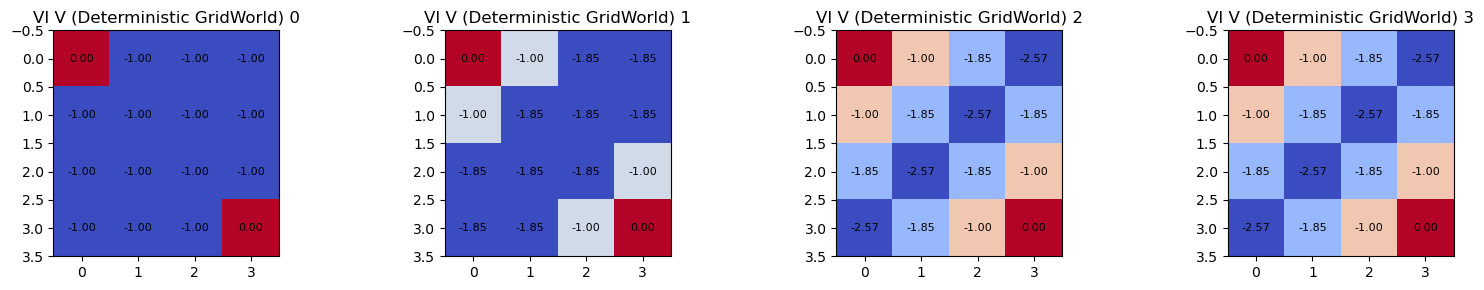

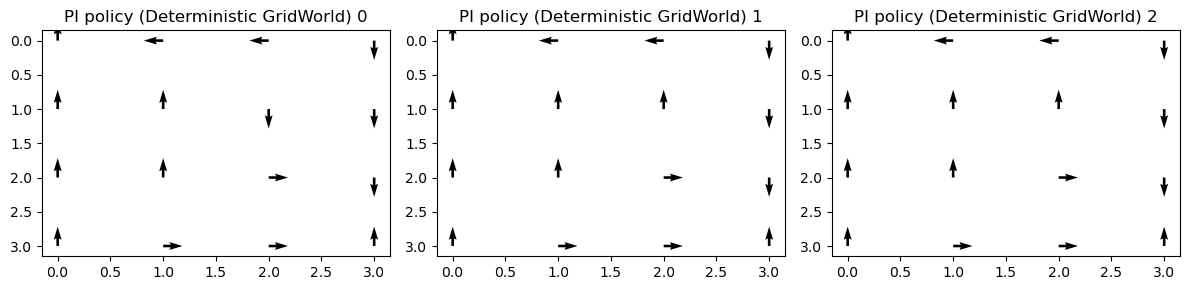

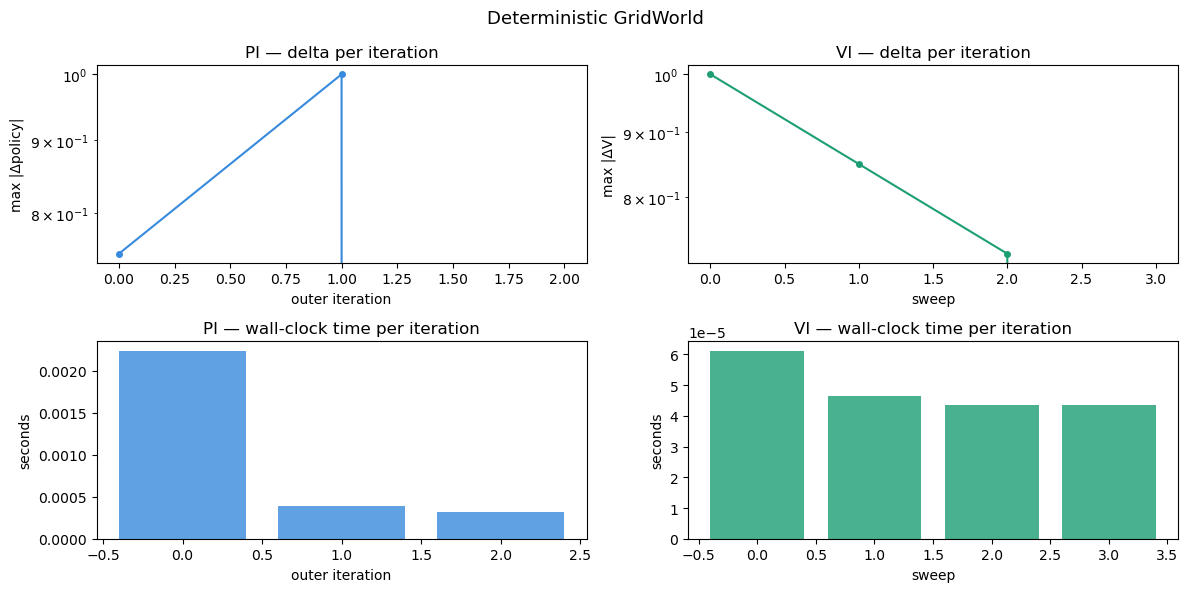


Stochastic GridWorld (slip=0.2)
T . . .
. . . .
. . . .
. . . T

Policy Iteration: iters=3, time=0.0014s
Value  Iteration: iters=6, time=0.0006s


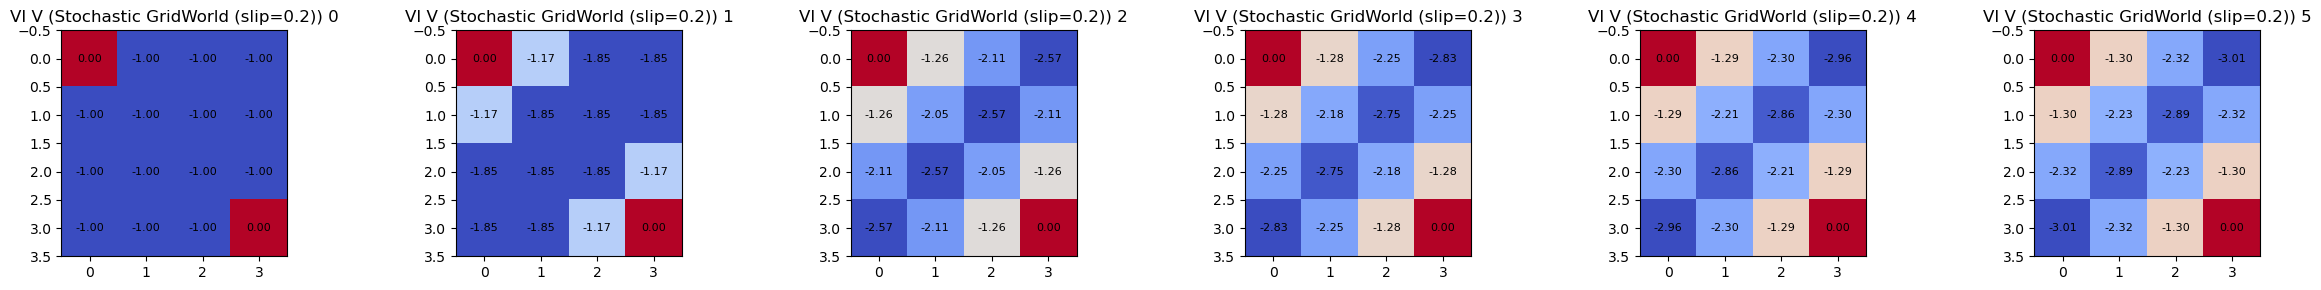

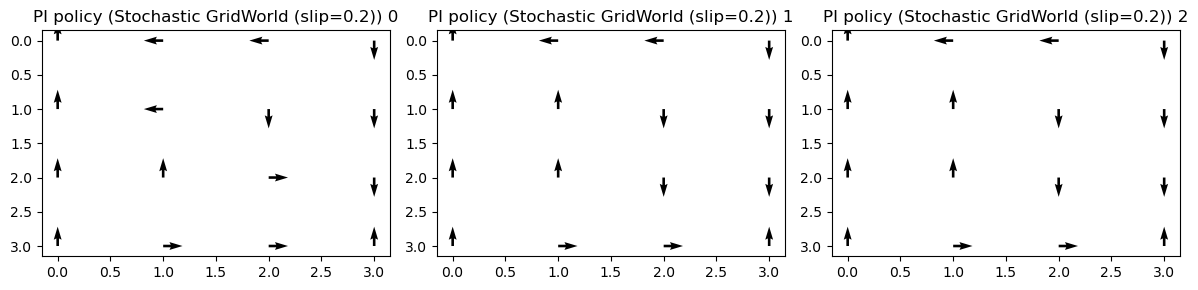

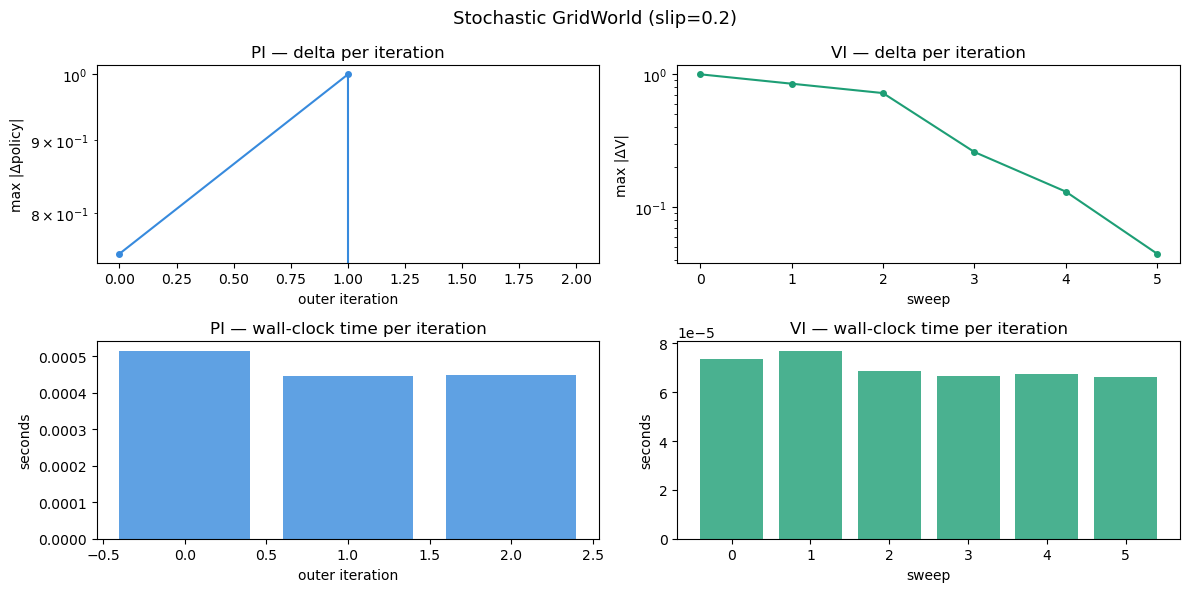

Gymnasium detected: FrozenLake adapter ready.


In [ ]:
gw_det = GridWorld(nrows=4, ncols=4, terminals=[0, 15],
                   default_reward=-1.0, slip_prob=0.0)
gw_sto = GridWorld(nrows=4, ncols=4, terminals=[0, 15],
                   default_reward=-1.0, slip_prob=0.2)

pi_det, vi_det   = run_experiment(gw_det, 'Deterministic GridWorld')
pi_sto, vi_sto   = run_experiment(gw_sto, 'Stochastic GridWorld (slip=0.2)')


# FROZENLAKE ADAPTER  
try:
    import gymnasium as gym

    def run_on_frozenlake(env_name='FrozenLake-v1', is_slippery=True,
                          map_name='4x4', gamma=0.85, theta=5e-2):
        env  = gym.make(env_name, is_slippery=is_slippery, map_name=map_name)
        P    = env.unwrapped.P
        nS   = env.observation_space.n
        nA   = env.action_space.n

        pol_vi, V_vi, Vhist_vi, deltas_vi, times_vi, its_vi, t_vi = \
            value_iteration(P, nS, nA, gamma=gamma, theta=theta)

        pol_pi, V_pi, p_hist_pi, V_hist_pi, deltas_pi, times_pi, its_pi, t_pi = \
            policy_iteration(P, nS, nA, gamma=gamma, theta=theta)

        return dict(
            value_iteration  =(pol_vi, V_vi, its_vi, t_vi),
            policy_iteration =(pol_pi, V_pi, its_pi, t_pi),
        )

    print('Gymnasium detected: FrozenLake adapter ready.')
except Exception:
    print('Gymnasium not available; FrozenLake experiments skipped.')